In [1]:
import pandas as pd
import numpy as np
import random

import sys, os
from tqdm import tqdm

sys.path.append(os.path.join(os.getcwd(), 'sql_engine_connection'))

from engine_connect import get_engine

import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime, timedelta

Pytania:
- Czy dane dla kazdego partnera pochodza z 1 strony czy z roznych?
- 

In [6]:
# # loading events table and saving it to json file data/events

# engine = get_engine()
# conn = engine.connect()

# df = pd.read_sql_query('select * from analytics.events', conn)
# df['collector_tstamp'] = df.collector_tstamp.apply(lambda x: datetime.utcfromtimestamp(x / 1000))
# df.to_json('data/events')

In [2]:
data = pd.read_json('data/events')
data['collector_tstamp'] = data.collector_tstamp.apply(lambda x: datetime.utcfromtimestamp(x / 1000))

In [3]:
data.head()

,partner_key,collector_tstamp,domain_userid,ab_slot1_variant,event_name,product_domain,product_id,variant_size_label,fitpredictor_fuxp_seed_brand,fitpredictor_fuxp_seed_category,fitpredictor_fuxp_seed_size,prediction_type,prediction_size,dvce_screenwidth
0,Partner B,2017-10-21 04:23:59,7fef686a7f46988a53fc280cc713d011f762482f,None,viewed_product,Female Bottoms,T63WE,None,None,None,None,None,None,320
1,Partner A,2018-04-14 22:22:59,fd4a2cb28ba50022d6a04a36ce8c9cc9ad932eb4,Test,viewed_product,Dresses,39053,None,None,None,None,mn,XS,1280
2,Partner A,2018-04-14 19:31:08,c4f893cba554ed80df6a92b7fe004b32558fd652,Control,viewed_product,Dresses,46595,None,None,None,None,None,None,375
3,Partner A,2018-04-13 17:07:26,02f2b1ac4f5afc7a96f9fa188f00ca8bee7b2510,Test,viewed_product,Dresses,3229646,None,None,None,None,None,None,1920
4,Partner B,2017-10-16 20:25:07,4b2098df581a0378bc599dd238fe1fe648685883,None,viewed_product,Male Tops,B2AEX,None,None,None,None,None,None,375


In [11]:
data.event_name.unique()

array(['viewed_product', 'added_variant_to_cart', 'opened_editor',
       'ordered_variant', 'selected_size', 'completed_profiling',
       'opened_brand_list', 'selected_category', 'selected_brand'],
      dtype=object)

In [4]:
df_A = data[data.partner_key == 'Partner A']
df_B = data[data.partner_key == 'Partner B']

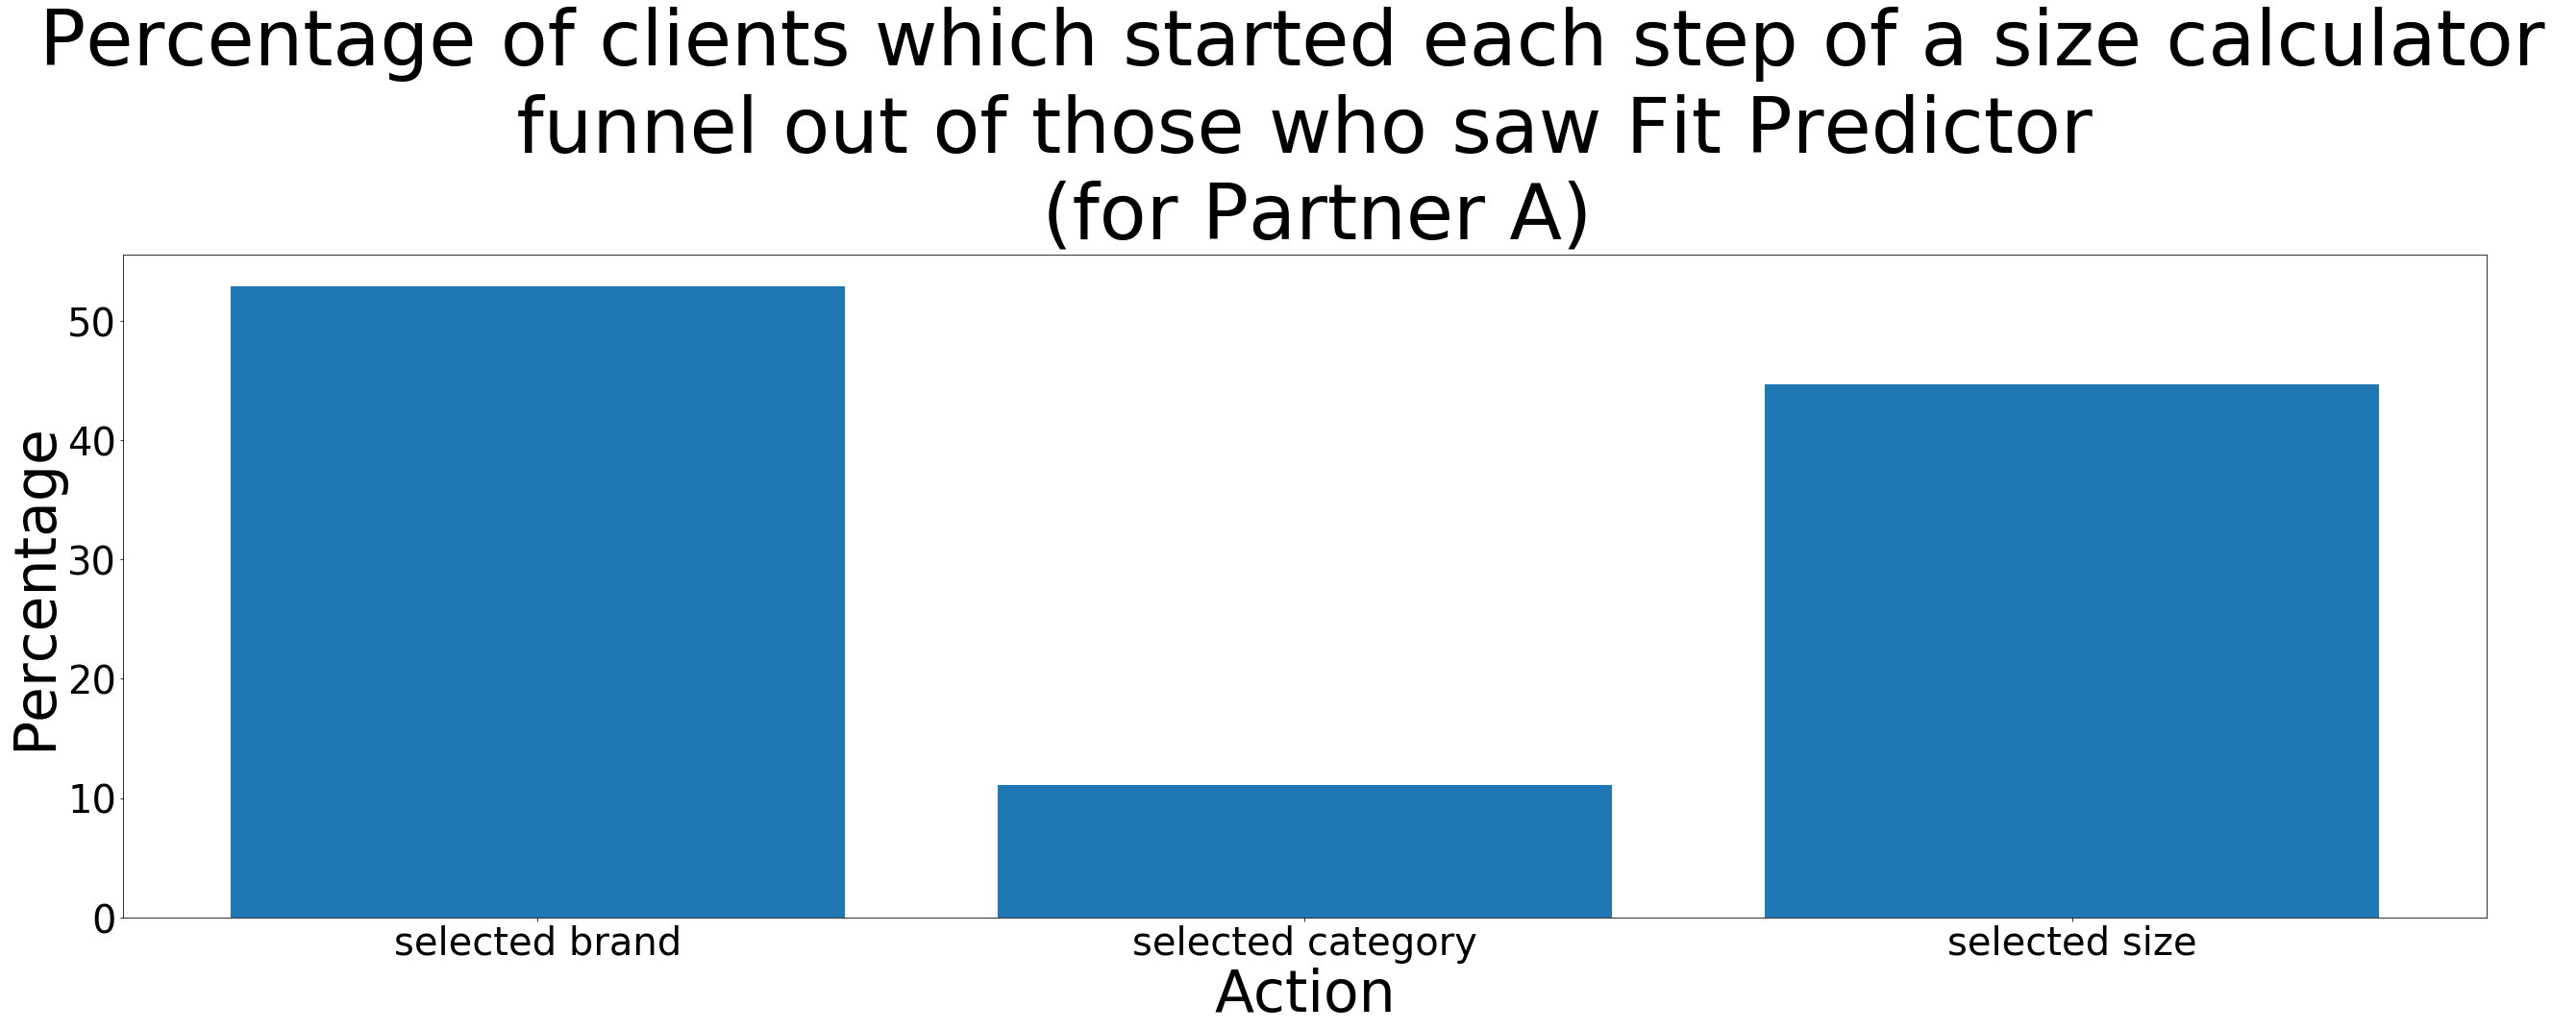

In [66]:
# how many users saw fit predictor
number_saw_fit_pred_A = df_A[df_A.event_name.apply(lambda x: x in ['opened_editor', 'selected_size', 'selected_brand', 
                                                                 'selected_category', 'completed_profiling', 
                                                                 'opened_brand_list'])].domain_userid.nunique()

number_selected_brand_A = df_A[df_A.event_name == 'selected_brand'].domain_userid.nunique()
number_selected_category_A = df_A[df_A.event_name == 'selected_category'].domain_userid.nunique()
number_selected_size_A = df_A[df_A.event_name == 'selected_size'].domain_userid.nunique()


fig, axes = plt.subplots(figsize = (40, 15))

axes.bar(['selected brand', 'selected category', 'selected size'], [number_selected_brand_A / number_saw_fit_pred_A * 100,
                                                                    number_selected_category_A / number_saw_fit_pred_A * 100, 
                                                                    number_selected_size_A / number_saw_fit_pred_A * 100])

axes.tick_params(labelsize = 40)
axes.set_ylabel('Percentage', fontsize = 60)
axes.set_xlabel('Action', fontsize = 60)
axes.set_title('Percentage of clients which started each step of a size calculator \n funnel out of those who saw Fit Predictor \n (for Partner A)', fontsize = 80)

fig.tight_layout()

plt.savefig('plots/task1_partnerA')

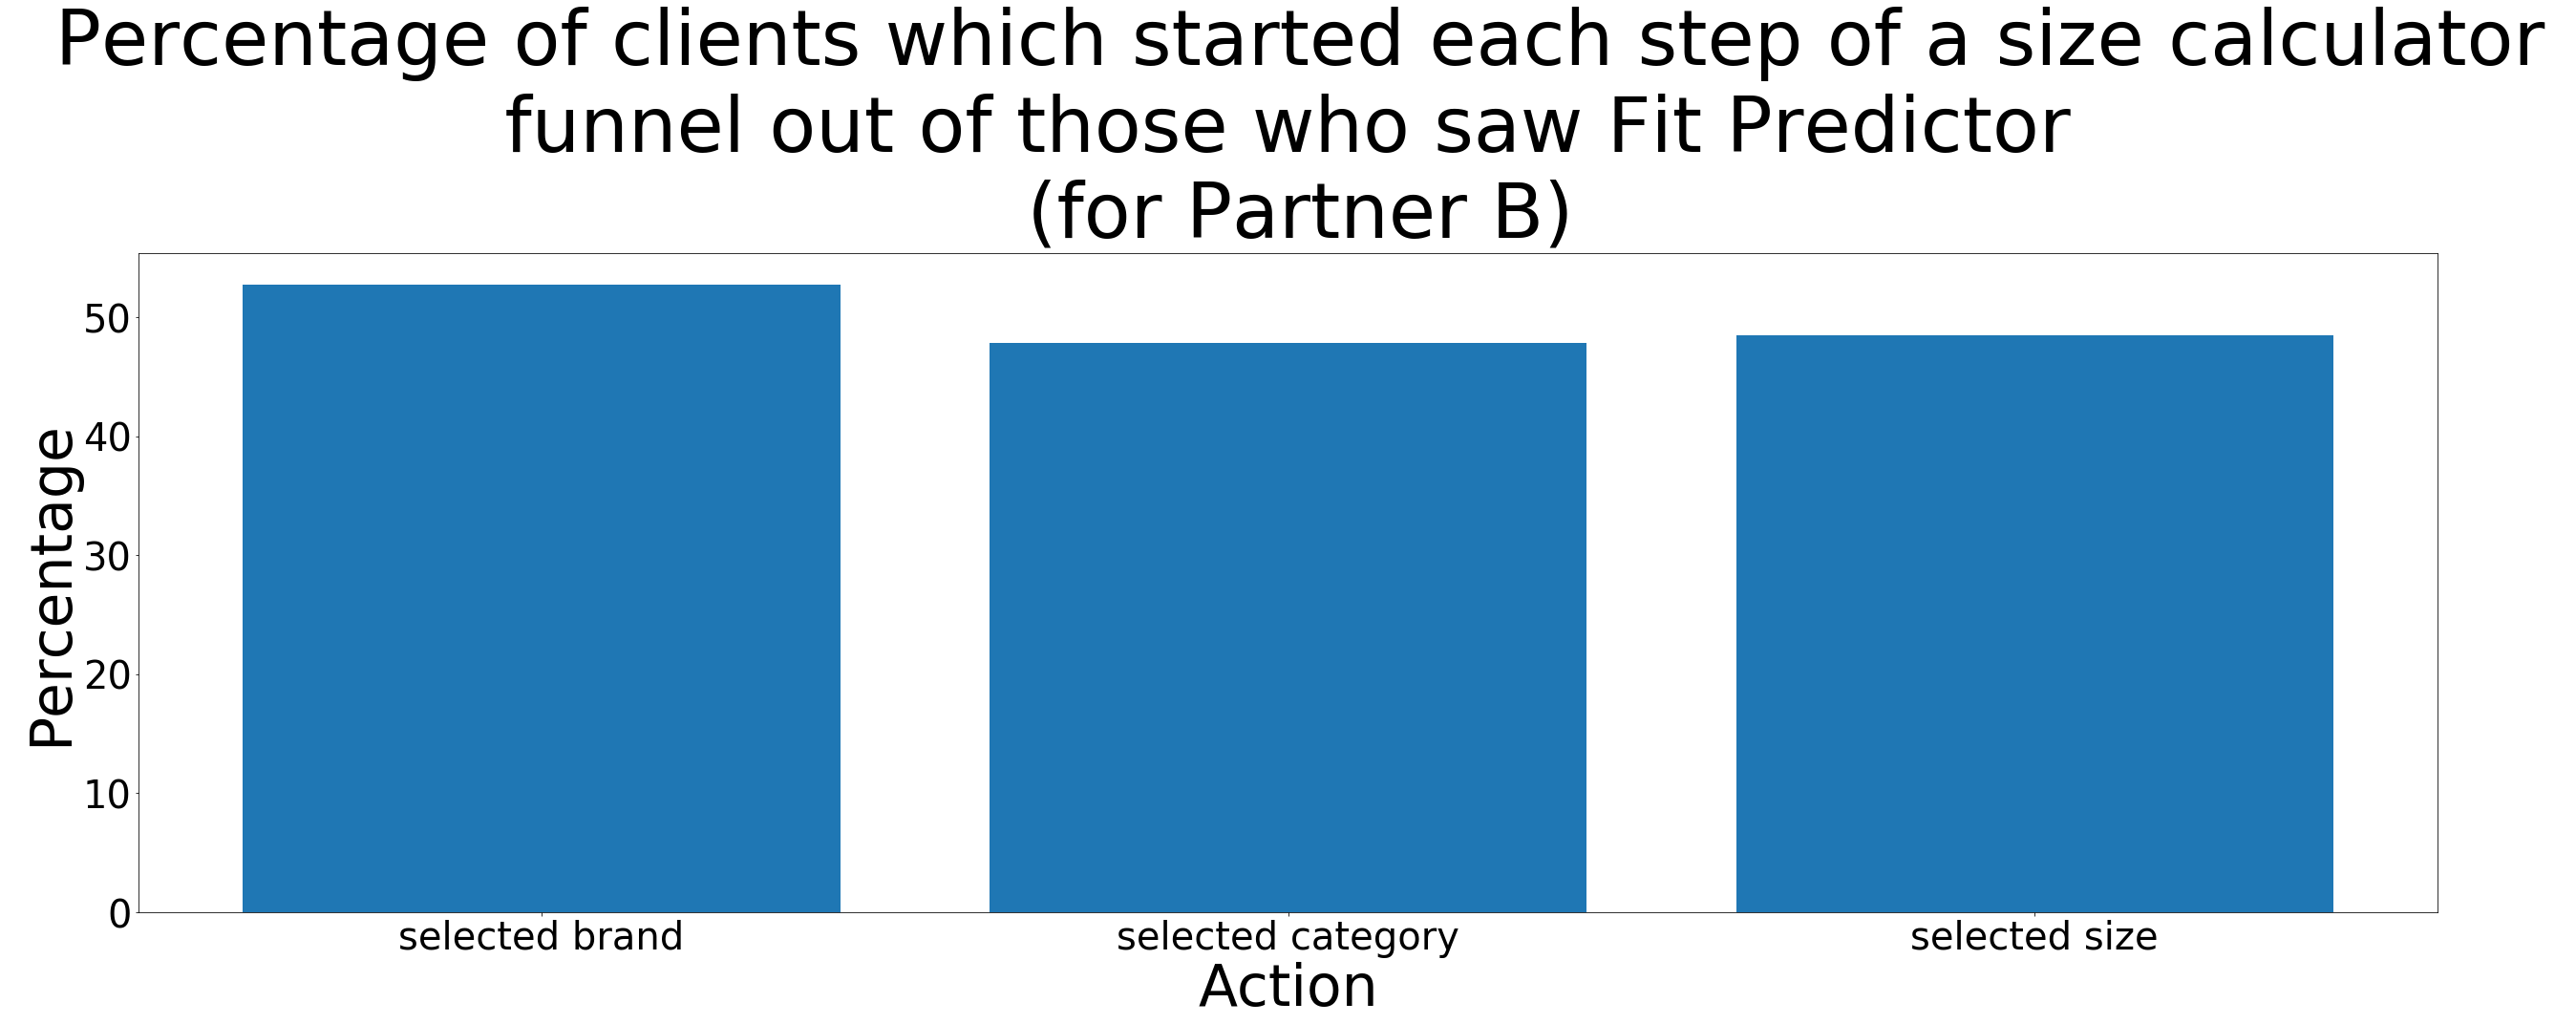

In [65]:
# how many users saw fit predictor
number_saw_fit_pred_B = df_B[df_B.event_name.apply(lambda x: x in ['opened_editor', 'selected_size', 'selected_brand', 
                                                                 'selected_category', 'completed_profiling', 
                                                                 'opened_brand_list'])].domain_userid.nunique()

number_selected_brand_B = df_B[df_B.event_name == 'selected_brand'].domain_userid.nunique()
number_selected_category_B = df_B[df_B.event_name == 'selected_category'].domain_userid.nunique()
number_selected_size_B = df_B[df_B.event_name == 'selected_size'].domain_userid.nunique()


fig, axes = plt.subplots(figsize = (40, 15))

axes.bar(['selected brand', 'selected category', 'selected size'], [number_selected_brand_B / number_saw_fit_pred_B * 100,
                                                                    number_selected_category_B / number_saw_fit_pred_B * 100, 
                                                                    number_selected_size_B / number_saw_fit_pred_B * 100])

axes.tick_params(labelsize = 40)
axes.set_ylabel('Percentage', fontsize = 60)
axes.set_xlabel('Action', fontsize = 60)
axes.set_title('  Percentage of clients which started each step of a size calculator \n funnel out of those who saw Fit Predictor \n (for Partner B)', fontsize = 80)

fig.tight_layout()

plt.savefig('plots/task1_partnerB')

In [45]:
number_selected_category_B

2496

In [46]:
number_selected_size_B

2527

For partner A there is more often situation such that there is no category to choose in the Fit Predictor

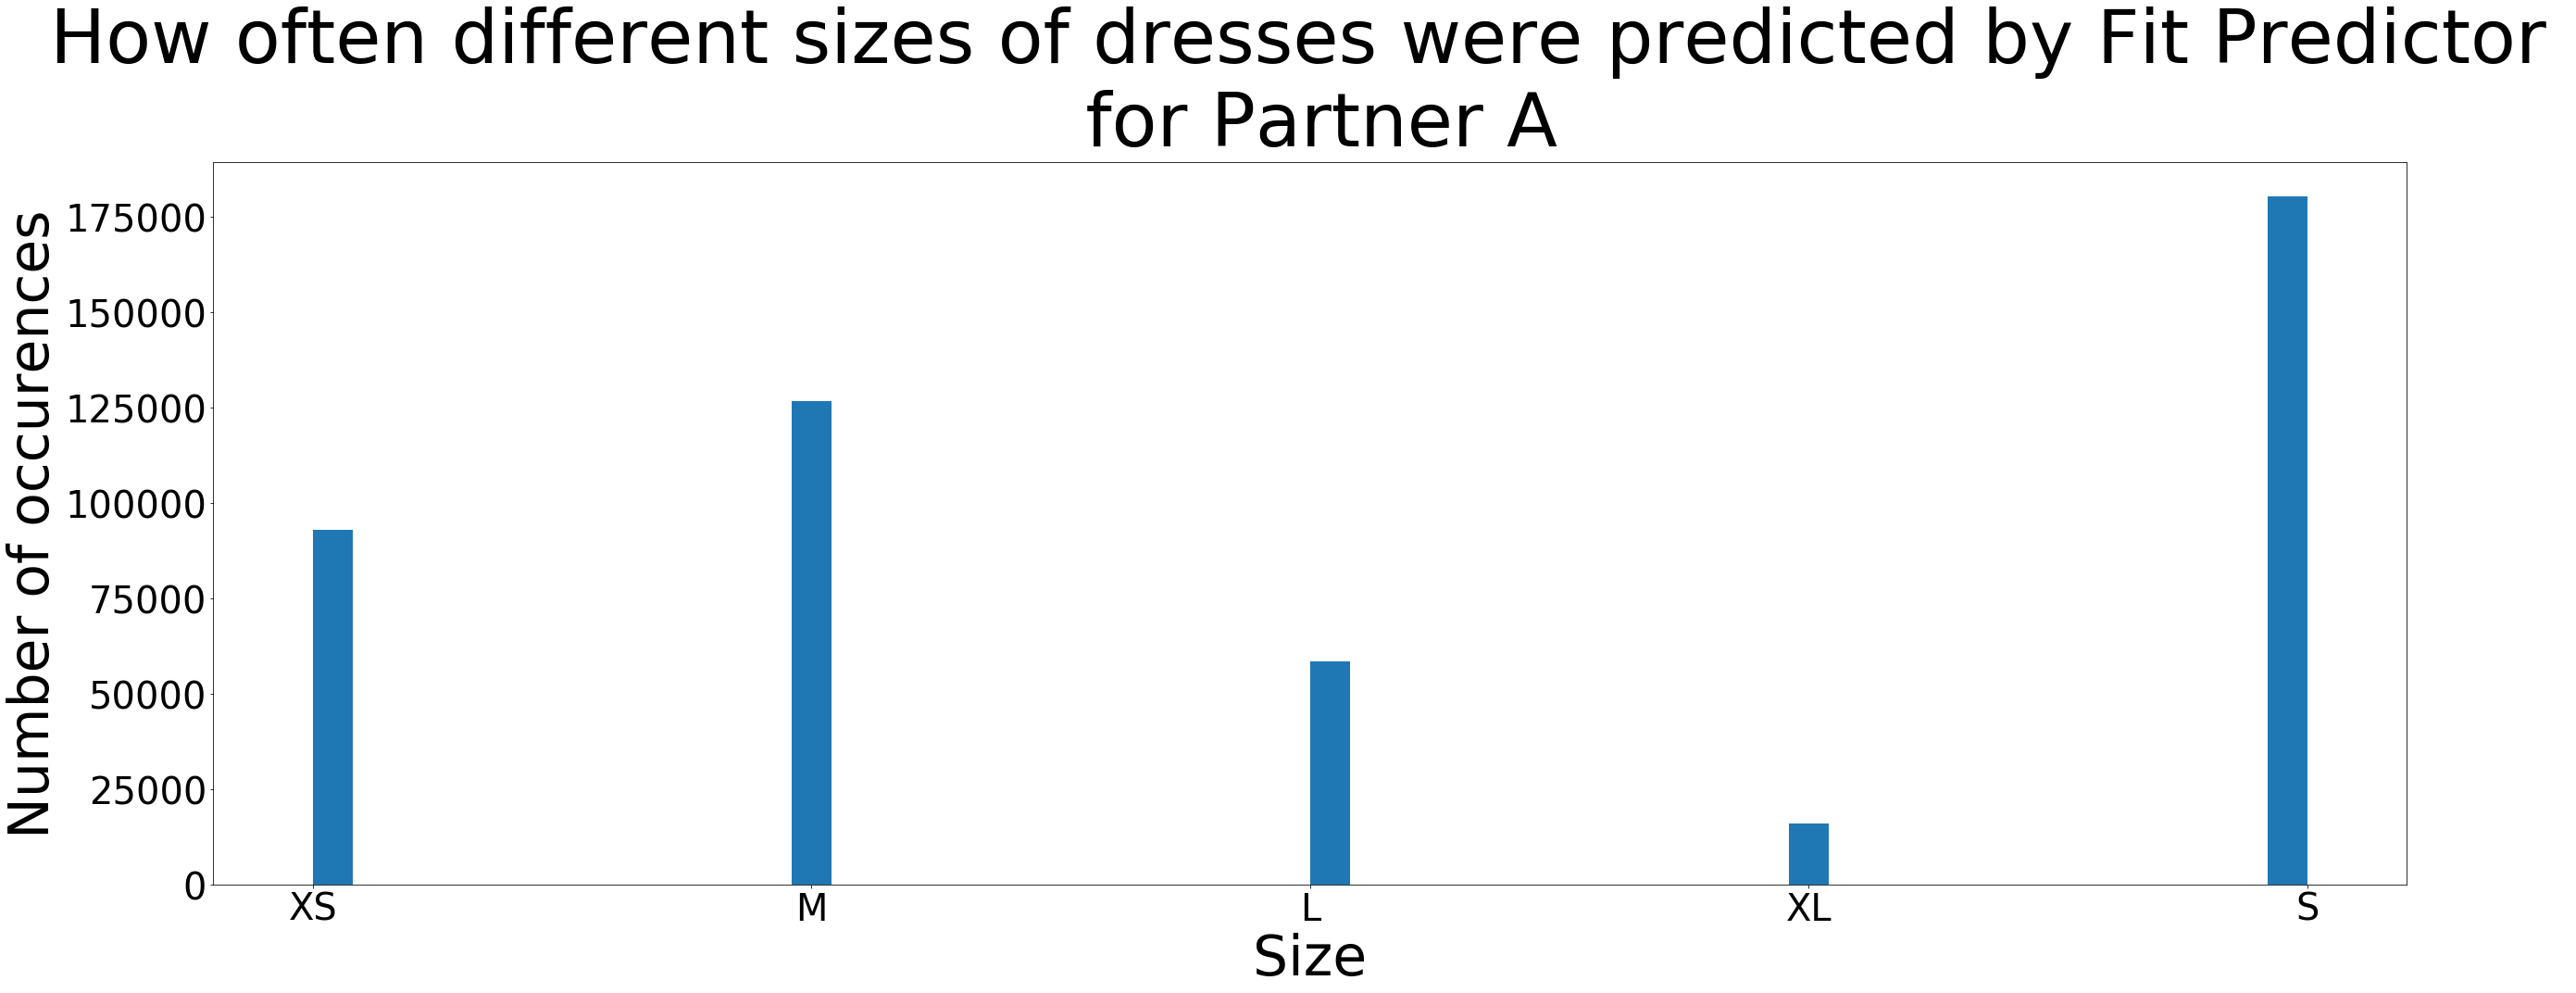

In [67]:
fig, axes = plt.subplots(figsize = (40, 15))

sizes = df_A[df_A.product_domain == 'Dresses'].prediction_size
sizes = sizes[sizes.apply(lambda x: x != None and x in ['XS', 'S', 'M', 'L', 'XL'])]

axes.hist(sizes, bins = 50)

axes.tick_params(labelsize = 40)
axes.set_ylabel('Number of occurences', fontsize = 60)
axes.set_xlabel('Size', fontsize = 60)

axes.set_title('How often different sizes of dresses were predicted by Fit Predictor \n for Partner A', fontsize = 80)
fig.tight_layout()

plt.savefig('plots/task3')

## graph 5

In [111]:
data.head()

,partner_key,collector_tstamp,domain_userid,ab_slot1_variant,event_name,product_domain,product_id,variant_size_label,fitpredictor_fuxp_seed_brand,fitpredictor_fuxp_seed_category,fitpredictor_fuxp_seed_size,prediction_type,prediction_size,dvce_screenwidth
0,Partner B,2017-10-21 04:23:59,7fef686a7f46988a53fc280cc713d011f762482f,None,viewed_product,Female Bottoms,T63WE,None,None,None,None,None,None,320
1,Partner A,2018-04-14 22:22:59,fd4a2cb28ba50022d6a04a36ce8c9cc9ad932eb4,Test,viewed_product,Dresses,39053,None,None,None,None,mn,XS,1280
2,Partner A,2018-04-14 19:31:08,c4f893cba554ed80df6a92b7fe004b32558fd652,Control,viewed_product,Dresses,46595,None,None,None,None,None,None,375
3,Partner A,2018-04-13 17:07:26,02f2b1ac4f5afc7a96f9fa188f00ca8bee7b2510,Test,viewed_product,Dresses,3229646,None,None,None,None,None,None,1920
4,Partner B,2017-10-16 20:25:07,4b2098df581a0378bc599dd238fe1fe648685883,None,viewed_product,Male Tops,B2AEX,None,None,None,None,None,None,375


In [28]:
bought_products = data[data.event_name == 'ordered_variant'][['domain_userid', 'product_id', 'collector_tstamp', 'variant_size_label', 'prediction_size']]
bought_products.head()

,domain_userid,product_id,collector_tstamp,variant_size_label,prediction_size
66,245ae4f9e61eb00b718ca26f2dadfe1971efcf4b,T6FRP,2017-10-15 17:21:09,NA,None
135,13a61b638c17b54c835467f6f4a6a734975f88a1,None,2018-04-14 16:51:12,M,None
246,ef0717882fcf750bb9d8e9fa6015cab6a81a552d,Z0H6Y,2017-10-13 21:22:08,L,None
434,73d817f049106f56600b0fe52568e70716dfe8b8,X0F4G,2017-10-15 17:26:50,NA,None
467,71fc6fbc1077937b7584410f583d73c3d3e6888f,T5EQS,2017-10-11 13:20:23,NA,None


In [189]:
fit_predictor_actions_data = data[data.event_name.apply(lambda x: x in ['selected_brand', 'selected_category', 'selected_size', 'complited_profiling'])]

def check_actions_taken(fit_predictor_actions_data, user, product, date_of_buying):
    actions_taken = []
    df = fit_predictor_actions_data[fit_predictor_actions_data.domain_userid == user]
    df = df[df.product_id == product]

    # take only rows with date close to the date of buying a product
    df = df[df.collector_tstamp.apply(lambda x: timedelta(seconds = 0) <= date_of_buying - x <= timedelta(days = 21))]
    
    if len(df) > 0:
        actions_taken = df.event_name.unique()
    else:
        actions_taken = []
    
    for i in range(4 - len(actions_taken)):
        actions_taken = np.concatenate((actions_taken, np.array([np.nan])))
            
    # pbar.update(1)
            
    return list(actions_taken)

# bought_products[['selected_brand', 'selected_category', 'selected_size', 'complited_profiling']] = 
# pbar = tqdm(total = 200)
df = bought_products[['domain_userid', 'product_id', 'collector_tstamp']].iloc[ : 200].apply(lambda x: check_actions_taken(fit_predictor_actions_data, x[0], x[1], x[2]), axis = 1)
# pbar.close()

In [193]:
df = np.array(list(df.values)).flatten()
df = pd.DataFrame(df.reshape(len(df) // 4, 4))
df

,0,1,2,3
0,nan,nan,nan,nan
1,nan,nan,nan,nan
2,nan,nan,nan,nan
3,nan,nan,nan,nan
4,nan,nan,nan,nan
...,...,...,...,...
195,nan,nan,nan,nan
196,nan,nan,nan,nan
197,nan,nan,nan,nan
198,nan,nan,nan,nan


In [134]:
user, product, date_of_buying = bought_products[['domain_userid', 'product_id', 'collector_tstamp']].iloc[0]

actions_taken = []
df = fit_predictor_actions_data[fit_predictor_actions_data.domain_userid == user]
df = df[df.product_id == product]

#     for event in ['selected_brand', 'selected_category', 'selected_size', 'complited_profiling']:
#         time_of_action = np.array([date for date in df[df.event_name == event].collector_tstamp])

#         # differences in time between buying and taking action
#         timedeltas = [np.abs(date_of_buying - time_of_action[i]) for i in range(len(time_of_action))]

#         if len(time_of_action) > 0 and timedelta(seconds = 0) <= np.min(timedeltas) <= timedelta(days = 21):
#             actions_taken.append(event)
#         else:
#             actions_taken.append(np.nan)

# take only rows with date close to the date of buying a product
# df = df[df.collector_tstamp.apply(lambda x: timedelta(seconds = 0) <= date_of_buying - x <= timedelta(days = 21))]
actions_taken = df.event_name.unique()

for i in range(4 - len(actions_taken)):
        actions_taken = np.concatenate((actions_taken, np.array([np.nan])))

In [47]:
data[data.event_name == 'selected_brand']

,partner_key,collector_tstamp,domain_userid,ab_slot1_variant,event_name,product_domain,product_id,variant_size_label,fitpredictor_fuxp_seed_brand,fitpredictor_fuxp_seed_category,fitpredictor_fuxp_seed_size,prediction_type,prediction_size,dvce_screenwidth
2275,Partner B,2017-10-19 02:15:48,d6d780ee2dc29b95d480b2b0b6b8d1a4c50959cd,None,selected_brand,Female Shoes,Z0BZW,None,Christian Louboutin,None,None,mn,10,1920
2466,Partner A,2018-04-14 06:09:56,0c927339df2aa4f5a62daace6573be81bfce56b5,Test,selected_brand,Dresses,91702,None,Topshop,Dresses,None,None,None,414
2505,Partner A,2018-04-13 15:48:53,ad272dbe78d47b3c87a9db7b0151e4820a6bb92c,Test,selected_brand,Dresses,97473,None,Lovers + Friends,Dresses,None,None,None,1280
2827,Partner A,2018-04-13 19:06:13,9b7442168eff7c97def148363ebfd827dd1299ed,Test,selected_brand,Female Bottoms,986099,S,Lucky Brand,None,None,None,None,1440
3152,Partner A,2018-04-13 00:32:28,882dd3d6ec80f20ed613d76646259424648c130a,Test,selected_brand,Dresses,72494,None,Nike,Dresses,None,None,None,1366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5952870,Partner A,2018-04-13 14:26:15,fc21a62ce3404428476b7564c238a4e77db1a649,Test,selected_brand,Dresses,44819,None,Z Supply,Dresses,None,None,None,1440
5953343,Partner A,2018-04-14 23:19:21,9990dee6126bcca50e049b3e17c37f2343c90ebe,Test,selected_brand,Dresses,49626,None,Free People,Dresses,None,None,None,375
5953504,Partner A,2018-04-13 18:30:20,ec26467457040fb40b6bc5ce01cc71af54b13474,Test,selected_brand,Dresses,55337,None,Lulus,Dresses,None,None,None,1280
5953596,Partner B,2017-10-20 16:54:44,b3810137a25908f87b0bcb818837eae951e04de6,None,selected_brand,Female Tops,I7672,None,Vince.,None,None,None,None,1440


In [42]:
len(bought_products[bought_products.completed_profiling]) / len(bought_products)

0.003150177832619583

In [44]:
bought_products[bought_products.completed_profiling]

,domain_userid,product_id,collector_tstamp,variant_size_label,prediction_size,completed_profiling
48169,0190aa77240fc140b6a7dc70a728d5cbba799685,B10UE,2017-10-14 02:01:14,XS,None,True
80784,1725c2f85c3b325dd9c7f8722fe37228eb117e7a,I7672,2017-10-11 06:06:43,38,None,True
85867,c445bba7d9c526eeed71a50796a4555429150a3b,Z0R5R,2017-10-14 19:22:45,NA,None,True
98150,c8f57a64a7e9dadca60850fd0cb61045667483dd,X252N,2017-10-20 16:43:38,L,None,True
142741,9d214160edf1f861037be286a93cc3620953138e,T2LTN,2017-10-12 21:31:02,7.5,None,True
...,...,...,...,...,...,...
5848592,8097fa62f733db6c06e8173df6bbe442d2b8ec21,H6LGF,2017-10-11 23:23:13,7,None,True
5878942,48f87a970a8f86f8c412adc8cb4db7c51bd3d0ea,I0CNA,2017-10-17 16:03:44,2,None,True
5888591,37be0073814830f4b140deb3031a1fa15513015e,S5499,2017-10-15 16:56:58,10,None,True
5903609,00366dd52ba9ae63cc9c04b5c86b85b52ba269e4,T4FHH,2017-10-14 01:55:27,8,None,True


In [43]:
bought_products

,domain_userid,product_id,collector_tstamp,variant_size_label,prediction_size,completed_profiling
66,245ae4f9e61eb00b718ca26f2dadfe1971efcf4b,T6FRP,2017-10-15 17:21:09,NA,None,False
135,13a61b638c17b54c835467f6f4a6a734975f88a1,None,2018-04-14 16:51:12,M,None,False
246,ef0717882fcf750bb9d8e9fa6015cab6a81a552d,Z0H6Y,2017-10-13 21:22:08,L,None,False
434,73d817f049106f56600b0fe52568e70716dfe8b8,X0F4G,2017-10-15 17:26:50,NA,None,False
467,71fc6fbc1077937b7584410f583d73c3d3e6888f,T5EQS,2017-10-11 13:20:23,NA,None,False
...,...,...,...,...,...,...
5953432,577328d3cb6db6ae324baa0960edebef8550e1be,T675H,2017-10-13 01:49:30,XS,None,False
5953911,94a7bc97dce97d9f7a0b38839184500ed938a403,B2HEX,2017-10-13 17:37:41,S,None,False
5953938,6835bed2b7348121ea160f19c1fa66aa31eb3cf4,N0LJS,2017-10-15 01:25:50,L,None,False
5954064,17212a6bb3b9847e9022119274da35e0bf0e1f7a,None,2018-04-14 01:55:24,5,None,False
